Companies House Data Science Workflow - Officer Nationality Analysis, Cleaning and Visualisation

Notebook Setup

In [5]:
# Install required libraries
!python -m pip install pandas seaborn matplotlib python-Levenshtein fuzzywuzzy requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Collect Company Numbers Automatically

In [6]:
import requests
import time

API_KEY = "bb873cea-13da-461d-9174-0838e66d4889"

queries = [
    "services",
    "consulting",
    "group",
    "holdings",
    "solutions",
    "management"
]

company_numbers = []

items_per_page = 100

for query in queries:

    start_index = 0

    while start_index < 300:   # limit per query

        url = f"https://api.company-information.service.gov.uk/search/companies?q={query}&items_per_page={items_per_page}&start_index={start_index}"

        response = requests.get(url, auth=(API_KEY, ""))

        if response.status_code != 200:
            break

        data = response.json()

        items = data.get("items", [])

        for company in items:

            number = company.get("company_number")

            if number and number not in company_numbers:
                company_numbers.append(number)

        start_index += items_per_page

        time.sleep(0.2)

print("Total unique companies:", len(company_numbers))

Total unique companies: 1800


Inspect Company List

In [7]:
company_numbers[:10]

['01692903',
 'SC423883',
 '16363569',
 '16002655',
 '15306682',
 '16086181',
 '14269085',
 '14272739',
 '14144630',
 '14236016']

Reduce Number of Companies

In [8]:
company_numbers = company_numbers[:1000]

print(len(company_numbers))

1000


Pull Officers for All Companies

In [9]:
officer_records = []

base_url = "https://api.company-information.service.gov.uk/company"

for company in company_numbers:

    start_index = 0
    items_per_page = 100

    while True:

        url = f"{base_url}/{company}/officers?items_per_page={items_per_page}&start_index={start_index}"

        response = requests.get(url, auth=(API_KEY, ""))

        if response.status_code != 200:
            break

        data = response.json()

        officers = data.get("items", [])

        if not officers:
            break

        for officer in officers:

            officer_records.append({
                "company_number": company,
                "name": officer.get("name"),
                "role": officer.get("officer_role"),
                "nationality": officer.get("nationality")
            })

        start_index += items_per_page

        time.sleep(0.2)

print("Total officers collected:", len(officer_records))

Total officers collected: 1374


Create DF

In [10]:
import pandas as pd

df = pd.DataFrame(officer_records)

df.head()

df.shape

(1374, 4)

Save Raw Dataset

In [11]:
df.to_csv("raw_officer_data.csv", index=False)

Identify Missing Data

In [12]:
df["nationality"].isna().sum()

np.int64(185)

Visualise Missing Data

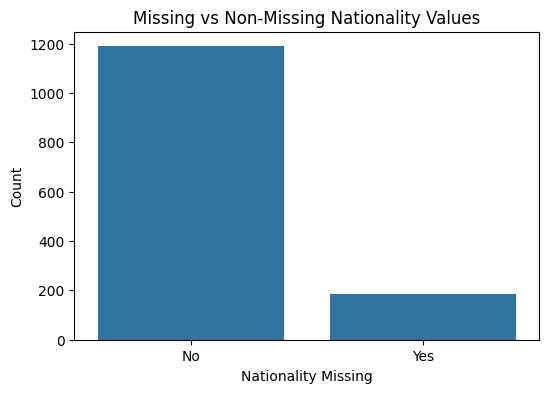

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

df['nationality_missing'] = df['nationality'].isna()

df['nationality_missing'].value_counts()

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='nationality_missing')

plt.title('Missing vs Non-Missing Nationality Values')
          
plt.xlabel('Nationality Missing')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])  
plt.show()


nationality_missing
False    1189
True      185
Name: count, dtype: int64


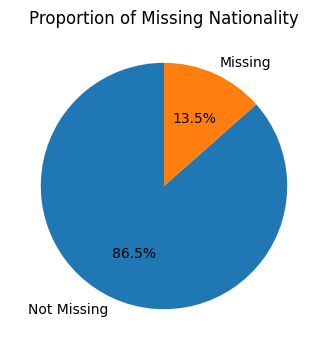

In [32]:
missing_counts = df['nationality_missing'].value_counts()

print(missing_counts)

plt.figure(figsize=(6, 4))
           
plt.pie(missing_counts, labels=['Not Missing', 'Missing'], autopct='%1.1f%%', startangle=90)

plt.title('Proportion of Missing Nationality')

plt.show()

Explore Nationality Variations

In [33]:
print(df["nationality"].value_counts().to_string())

nationality
British           893
Pakistani          28
French             25
Romanian           23
English            19
Italian            17
Polish             15
American           13
Indian             12
New Zealander      11
Australian          9
Moroccan            9
Portuguese          8
Dutch               8
Nigerian            7
Ukrainian           5
Algerian            5
Irish               5
Greek               4
Latvian             4
German              4
Spanish             4
Moldovan            4
Swedish             4
Belgian             3
Malagasy            3
Argentine           3
South African       3
Egyptian            3
Ghanaian            2
Canadian            2
Kenyan              2
New Zealand         2
Finnish             2
Swiss               2
Tunisian            1
Danish              1
Nigerien            1
Venezuelan          1
Usa                 1
Brazilian           1
Beninese            1
Afghan              1
Kuwaiti             1
Lithuanian          

Normalise Nationality Formatting

In [34]:
df['nationality_normalized'] = (df['nationality']).str.strip().str.lower()

Mapping Dictionary

In [35]:
mapping = {
    "english": "british", 'scottish': 'british', 'welsh': 'british', 'brtish': 'british', 'nigerien':'nigerian', 'usa':'american','new zealand':'new zealander'}

df['nationality_clean'] = df['nationality_normalized'].replace(mapping)

In [36]:
df['nationality_clean'].value_counts()

nationality_clean
british           914
pakistani          28
french             25
romanian           23
italian            17
polish             15
american           14
new zealander      13
indian             12
australian          9
moroccan            9
portuguese          8
nigerian            8
dutch               8
ukrainian           5
algerian            5
irish               5
greek               4
german              4
spanish             4
latvian             4
swedish             4
moldovan            4
egyptian            3
south african       3
belgian             3
argentine           3
malagasy            3
kenyan              2
ghanaian            2
canadian            2
finnish             2
swiss               2
danish              1
beninese            1
brazilian           1
tunisian            1
maltese             1
israeli             1
russian             1
tanzanian           1
lithuanian          1
afghan              1
kuwaiti             1
venezuelan    

Convert to Categorical

In [37]:
df["nationality_clean"] = df["nationality_clean"].astype("category")

British vs Non-British Groupby Analysis

In [38]:
df["british_flag"] = df["nationality_clean"].apply(
    lambda x: "British" if x == "british" else "Non-British"
)

In [39]:
role_nationality = df.groupby(["role","british_flag"]).size().reset_index(name="count")

role_nationality

,role,british_flag,count
0,director,British,812
1,director,Non-British,268
2,nominee-director,British,2
3,secretary,British,100
4,secretary,Non-British,7


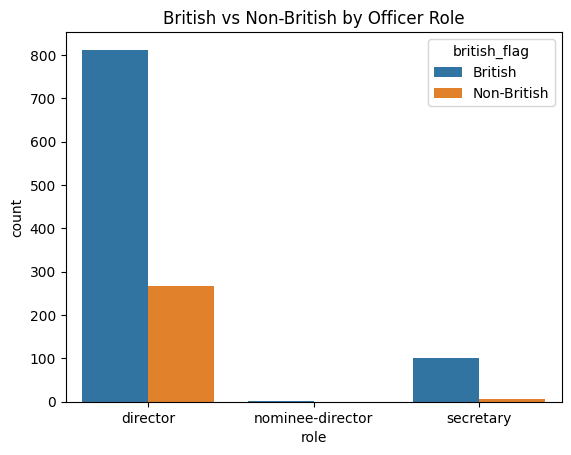

In [40]:
sns.barplot(
    data=role_nationality,
    x="role",
    y="count",
    hue="british_flag"
)

plt.title("British vs Non-British by Officer Role")

plt.show()

In [41]:
percentage = df.groupby("role")["british_flag"].value_counts(normalize=True)

percentage

role              british_flag
director          British         0.751852
                  Non-British     0.248148
nominee-director  British         1.000000
secretary         British         0.934579
                  Non-British     0.065421
Name: proportion, dtype: float64

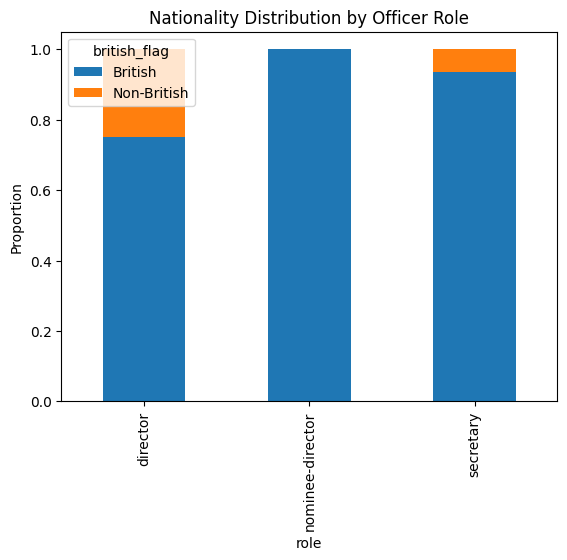

In [42]:
percentage.unstack().plot(kind="bar", stacked=True)

plt.ylabel("Proportion")

plt.title("Nationality Distribution by Officer Role")

plt.show()

Continent Groupby Analysis

In [67]:
continent_mapping = {

    # Europe
    "british": "Europe",
    "irish": "Europe",
    "northern irish": "Europe",
    "french": "Europe",
    "romanian": "Europe",
    "italian": "Europe",
    "polish": "Europe",
    "dutch": "Europe",
    "ukrainian": "Europe",
    "portuguese": "Europe",
    "greek": "Europe",
    "german": "Europe",
    "spanish": "Europe",
    "latvian": "Europe",
    "swedish": "Europe",
    "moldovan": "Europe",
    "belgian": "Europe",
    "finnish": "Europe",
    "swiss": "Europe",
    "danish": "Europe",
    "maltese": "Europe",
    "russian": "Europe",
    "lithuanian": "Europe",
    "austrian": "Europe",
    "bulgarian": "Europe",
    "albanian": "Europe",

    # Africa
    "nigerian": "Africa",
    "moroccan": "Africa",
    "algerian": "Africa",
    "egyptian": "Africa",
    "south african": "Africa",
    "ghanaian": "Africa",
    "kenyan": "Africa",
    "tunisian": "Africa",
    "beninese": "Africa",
    "tanzanian": "Africa",
    "sierra leonean": "Africa",
    "malagasy": "Africa",

    # Asia
    "indian": "Asia",
    "pakistani": "Asia",
    "israeli": "Asia",
    "afghan": "Asia",
    "kuwaiti": "Asia",
    "yemeni": "Asia",
    "chinese": "Asia",
    "filipino": "Asia",

    # North America
    "american": "North America",
    "canadian": "North America",

    # South America
    "argentine": "South America",
    "brazilian": "South America",
    "venezuelan": "South America",
    "ecuadorean": "South America",

    # Oceania
    "australian": "Oceania",
    "new zealander": "Oceania",

    # Other / Unknown
    "other": "Other/Unknown",
    "unknown": "Other/Unknown"
}

In [68]:
df["continent"] = df["nationality_clean"].map(continent_mapping)

In [69]:
df[df["continent"].isna()]["nationality_clean"].unique()   

[NaN]
Categories (55, object): ['afghan', 'albanian', 'algerian', 'american', ..., 'tunisian', 'ukrainian', 'venezuelan', 'yemeni']

In [70]:
continent_counts = df["continent"].value_counts() 
continent_counts


continent
Europe           1059
Asia               46
Africa             39
Oceania            22
North America      16
South America       6
Other/Unknown       1
Name: count, dtype: int64

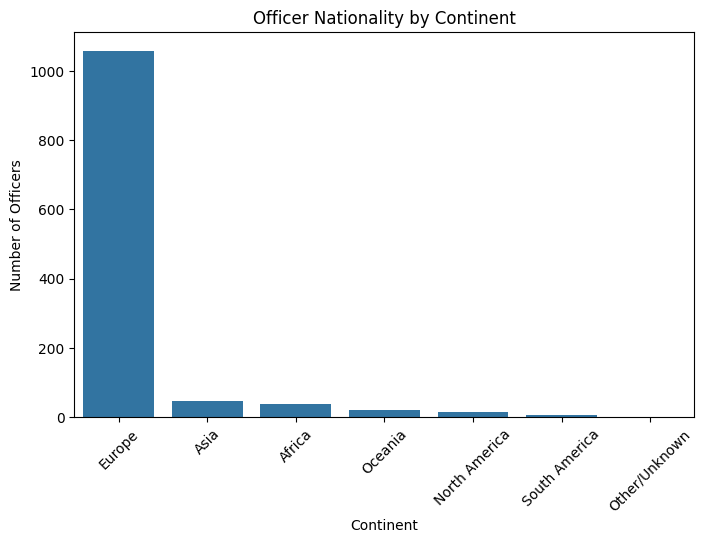

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=continent_counts.index,
    y=continent_counts.values
)

plt.title("Officer Nationality by Continent")

plt.xlabel("Continent")
plt.ylabel("Number of Officers")

plt.xticks(rotation=45)

plt.show()

FATF 'grey' and 'black' list country

In [72]:
fatf_mapping = {

    # Black list
    "northern korean": "Black List",
    "iranian": "Black List",
    "myanmar": "Black List",

    # Grey list
    "algerian": "Grey List",
    "angolan": "Grey List",
    "bolivian": "Grey List",
    "bulgarian": "Grey List",
    "cameroonian": "Grey List",
    "ivory coast": "Grey List",
    "congolese": "Grey List",
    "haitian": "Grey List",
    "kenyan": "Grey List",
    "kuwaiti": "Grey List",
    "laoan": "Grey List",
    "lebanese": "Grey List",
    "namibian": "Grey List",
    "nepalese": "Grey List",
    "south sudanese": "Grey List",
    "papa new guinean": "Grey List",
    "syrian": "Grey List",
    "venezuelan": "Grey List",
    "vietnamese": "Grey List",
    "yemeni": "Grey List",

}

In [73]:
df["fatf_status"] = df["nationality_clean"].map(fatf_mapping)
df["fatf_status"] = df["fatf_status"].fillna("Not Listed")

In [74]:
df["fatf_status"].value_counts()

fatf_status
Not Listed    1363
Grey List       11
Name: count, dtype: int64

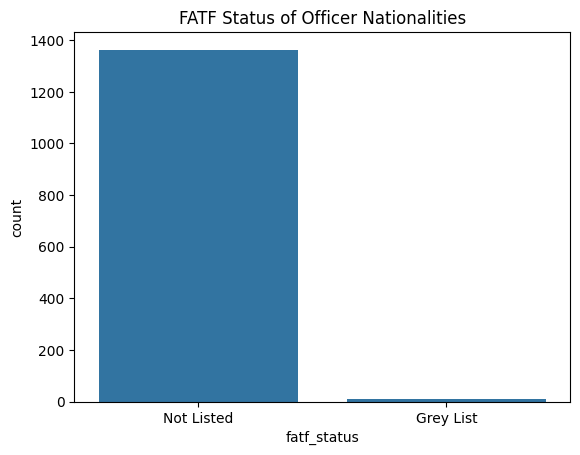

In [75]:
sns.countplot(data=df, x="fatf_status")
plt.title("FATF Status of Officer Nationalities")
plt.show()